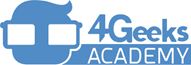

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 16</b>: Introducción Machine Learning</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. ¿Qué era Machine learning?](#ml)
- [2. Tipos de aprendizaje](#aprendizajes)
- [3. Conjunto de datos](#aprendizajes)
- [4. Sobreajuste (overfiting) vs subajuste (underfiting)](#overfiting)
- [5. Métricas](#metricas)
- [6. Optimización de hiperparámetros](#hiperparametros)
- [7. Regresión logística](#logistica)
  - [7.1. Función logarítmica](#funcion)
  - [7.2. Umbral de decisión](#umbral)
  - [7.3. Hiperparámetros](#parametros)
- [8. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


## 1. ¿Qué era Machine learning? <a name="ml"></a>

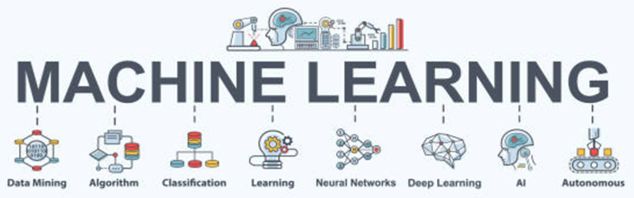

El Aprendizaje Automático (Machine learning) es una rama de la Inteligencia Artificial que se centra en la construcción de sistemas que pueden aprender de los datos, en lugar de seguir solo reglas programadas explícitamente.

Por ejemplo, un modelo de Machine Learning podría ser entrenado para reconocer gatos al proporcionarle miles de imágenes con y sin gatos.

Con suficientes ejemplos, el sistema "aprende" a distinguir las características que definen a un gato, así podría identificarlos en nuevas imágenes que nunca antes había visto.

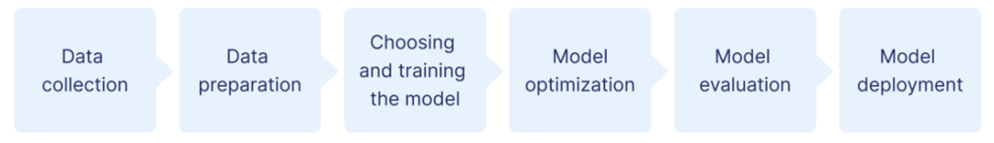

## 2. Tipos de aprendizaje <a name="aprendizajes"></a>

Existen varios tipos de aprendizajes basados en la forma en que el algoritmo aprende a partir de los datos.

###Aprendizaje supervisado (Supervised Learning)

El modelo se entrena con un conjunto de datos etiquetados, lo que significa que cada ejemplo de entrenamiento está asociado con una etiqueta o salida deseada (objetivo).

Hay dos tipos de problemas supervisados:

- **Regresión** (*regression*). Cuando la etiqueta o el valor objetivo es un número continuo (como el precio de una casa), el problema se considera un problema de regresión. El modelo debe devolver un número en una escala infinita.

- **Clasificación** (*classification*). Cuando la etiqueta es categórica (como predecir si un correo es spam o no), el problema es de clasificación. El modelo debe devolver una etiqueta según se corresponda a una clase u otra.

**Ejemplos de algoritmos**: regresión lineal, regresión logística, máquinas de soporte vectorial (SVM), redes neuronales, árboles de decisión.

**Ejemplos de aplicaciones**: clasificación de correos electrónicos como spam o no spam, predicción de precios de viviendas.

###Aprendizaje no Supervisado (unsupervised Learning)

Los modelos se entrenan usando un conjunto de datos sin etiquetas.

En este tipo de aprendizaje, el objetivo es encontrar patrones o estructuras ocultas en los datos.

Puesto que en este tipo de aprendizaje no hay etiquetas, los modelos deben descubrir por sí mismos las relaciones en los datos.

**Ejemplos de algoritmos**: k-means, clustering jerárquico, análisis de componentes principales (PCA), redes neuronales autoencodificadoras.

**Ejemplos de aplicaciones**: segmentación de clientes, reducción de dimensionalidad.

###Aprendizaje por refuerzo (reinforcement Learning)

En este aprendizaje el modelo (también llamado agente) aprende a tomar decisiones óptimas a través de la interacción con su entorno.

El objetivo es maximizar alguna noción de recompensa acumulativa.

En el aprendizaje por refuerzo, el agente toma acciones, las cuales afectan el estado del ambiente, y recibe retroalimentación en forma de recompensas o penalizaciones.

La meta es aprender una estrategia para maximizar su recompensa a largo plazo.

Un ejemplo de este tipo de aprendizaje es un programa que aprenda a jugar al ajedrez. El agente (el programa) decide qué movimiento hacer (las acciones de mover ficha) en diferentes posiciones del tablero de ajedrez (los estados) para maximizar la posibilidad de ganar el juego (la recompensa).

El aprendizaje por refuerzo está centrado en tomar decisiones óptimas y aprender a partir de la retroalimentación de esas decisiones.

**Ejemplos de algoritmos**: Q-learning, SARSA, aprendizaje profundo por refuerzo (Deep Q-Networks).

**Ejemplos de aplicaciones**: juegos (como AlphaGo), robótica, conducción autónoma.

###Aprendizaje semi supervisado (semi supervised Learning)

Combina una pequeña cantidad de datos etiquetados con una gran cantidad de datos no etiquetados durante el entrenamiento.

Útil cuando etiquetar datos es costoso o difícil, pero se dispone de una gran cantidad de datos no etiquetados.

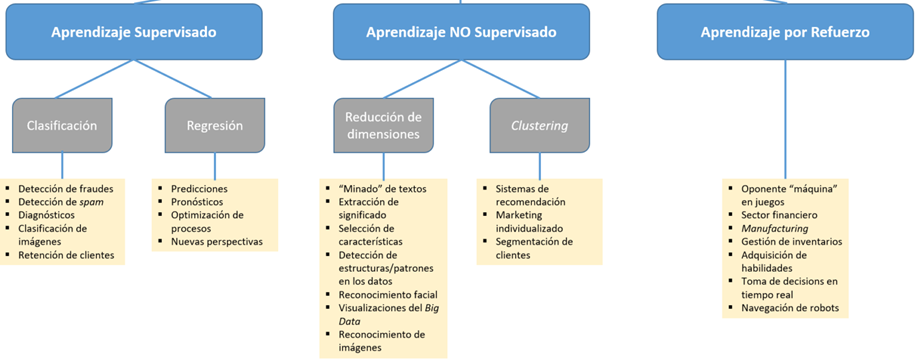

Tambien podemos ampliar a otras clasificaciones como aprendizaje por transferencia (transfer learning) o profundo (deep learning).

Por transferencia aprovecha un modelo previamente entrenado en una tarea específica y lo adapta a una nueva tarea relacionada. Ejemplos de aplicaciones: reconocimiento de imágenes, procesamiento del lenguaje natural (NLP).

Deep learning será subcampo del aprendizaje supervisado y no supervisado que utiliza redes neuronales artificiales con muchas capas (redes neuronales profundas). Ejemplos de aplicaciones: reconocimiento de voz, traducción automática, generación de imágenes.

## 3. Conjunto de datos <a name="aprendizajes"></a>

Un conjunto de datos es una colección que normalmente se representa en forma de tabla. En esta tabla, cada fila representa una observación o instancia y cada columna representa una característica, atributo o variable de esa observación.

Este conjunto de datos es utilizado para entrenar y evaluar modelos.

**Entrenamiento del modelo**. Un modelo de Machine Learning aprende a partir de un conjunto de datos de entrenamiento. El modelo entrena ajustando sus parámetros internamente.

**Evaluación del modelo**. Una vez que el modelo ha sido entrenado, se utiliza un conjunto de datos de prueba independiente para evaluar su rendimiento. Este dataset contiene observaciones que no se utilizaron durante el entrenamiento, lo que permite obtener una evaluación imparcial de cómo se espera que el modelo realice predicciones sobre nuevos datos.

En algunas situaciones, también se utiliza un conjunto de validación, que se utiliza para evaluar el rendimiento de un modelo durante el entrenamiento. Una vez que se entrenan los modelos, se evalúan en el conjunto de validación para seleccionar el mejor modelo posible.

### Split de datos

El paso previo de entrenar un modelo, además del EDA, es dividir los datos en un conjunto de entrenamiento (train dataset) y un conjunto de prueba (test dataset).

Seleccionaremos aleatoriamente un 80% (puede variar) de las filas y las colocaremos en el conjunto de entrenamiento y el 20% restante en el conjunto de prueba.

Entrena el modelo usando el conjunto de entrenamiento (X_train, y_train).

Prueba el modelo usando el conjunto de prueba (X_test, y_test).

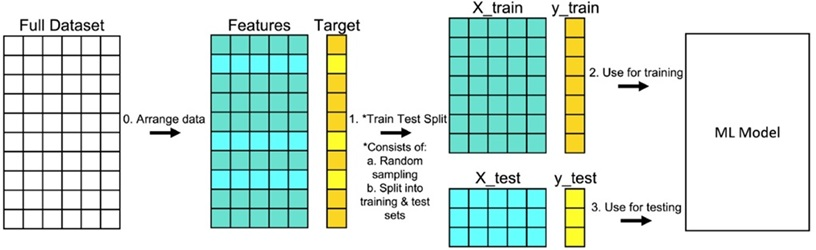

In [ ]:
# Cargamos el conjunto de datos
total_data = sns.load_dataset("attention")

total_data.head()

In [ ]:
features = ["subject", "attention", "solutions"]
target = "score"

# Separamos las predictoras de la etiqueta
X = total_data[features]
y = total_data[target]

# Dividimos la muestra en train y test al 80%
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20, train_size = 0.80)

## 4. Sobreajuste (overfiting) vs subajuste (underfiting) <a name="overfiting"></a>

Se pueden dar diversos escenarios relacionados con el rendimiento de un modelo.

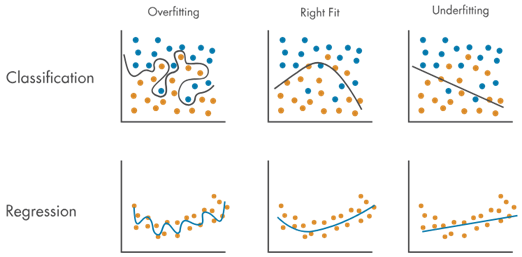

**Sobreajuste (overfiting)**

Un modelo aprende demasiado bien los detalles y el ruido de los datos de entrenamiento, en lugar de aprender los patrones subyacentes que son realmente útiles para predecir datos nuevos.

Esto hace que el modelo funcione extremadamente bien en los datos de entrenamiento, pero falle al generalizar y predecir correctamente en datos no vistos (datos de prueba o datos nuevos).

Indicadores de overfiting:
- Alto rendimiento en train y bajo en test.
- Grandes diferencias entre el error de train y test.
- Usando validaciones cruzadas sigue dando sobreajuste.

Posibles causas:
- Modelo demasiado complejo para el problema.
- Datos insuficientes para entrenar.
- Ruido en los datos.

Técnicas para prevenir:
- Usar bien el split de datos.
- Validazión cruzdaa.
- Reducir la complejidad del modelo. Por ejemplo: con regularización.
- Aumentar la cantidad de datos.
- Usar métodos de ensamble.


**Subajuste (underfiting)**

Ocurre cuando un modelo es demasiado simple para capturar la estructura subyacente de los datos.

Esto resulta en un bajo rendimiento tanto en el conjunto de entrenamiento como en el de prueba.

Indicadores de underfiting:
- Bajo rendimiento en train y test.

Posibles causas:
- Modelo demasiado simple para el problema.
- Datos insuficientes para entrenar.
- Faltas de carácteristicas relevantes en los datos para el objetivo.

Técnicas para prevenir:
- Aumentar la complejidad del modelo.
- Añadir carácterísticas relevantes.
- Aumentar la cantidad de datos.

**Ajuste justo (good fit)**

Este es el escenario ideal donde el modelo generaliza bien tanto en los datos de entrenamiento como en los datos de prueba.

El modelo ha aprendido los patrones subyacentes sin sobreajustarse al ruido de los datos de entrenamiento.

Indicadores de ajuste justo:
- Buena métrica tanto en train como test.
- Los errores no son muy distintos en ambos conjuntos.

Técnicas para mantener un ajuste bueno:
- Validar los modelos con nuevos datos continuamente.
- Evitar añadir complejidad innecesaria.

## 5. Métricas <a name="metricas"></a>

La **evaluación** de un modelo es uno de los pasos más importantes en el proceso de Machine Learning, ya que nos va a permitir saber cómo de bueno es nuestro modelo, cuánto ha aprendido de la muestra de entrenamiento (`train`) y cómo procederá para datos nunca vistos o nuevos (`test` y/o `validación`).

Para evaluar un modelo existen métricas según el tipo de problema y aprendizaje.

El paquete `scikit-learn` permite fácilmente aplicar estas funciones a los modelos. La documentación está accesible [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

### Métricas para modelos de clasificación

Un **modelo de clasificación** se utiliza para predecir una categoría o la clase de una observación.

Conceptos claves:

- Verdaderos Positivos (TP): Número de ejemplos positivos que el modelo clasificó correctamente como positivas.

- Verdaderos Negativos (TN): Número de ejemplos negativos que el modelo clasificó correctamente como negativas.

- Falsos Positivos (FP): Número de ejemplos negativos que el modelo clasificó incorrectamente como positivas.

- Falsos Negativos (FN): Número de ejemplos positivos que el modelo clasificó incorrectamente como negativas.


Las métricas que se pueden aplicar a este tipo de modelos son las siguientes:

- **Matriz de confusión**: La matriz compara los valores predichos con los valores reales.

Buscamos valores altos en la diagonal.

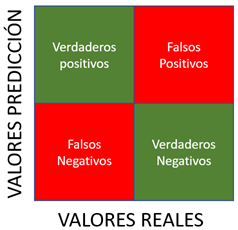

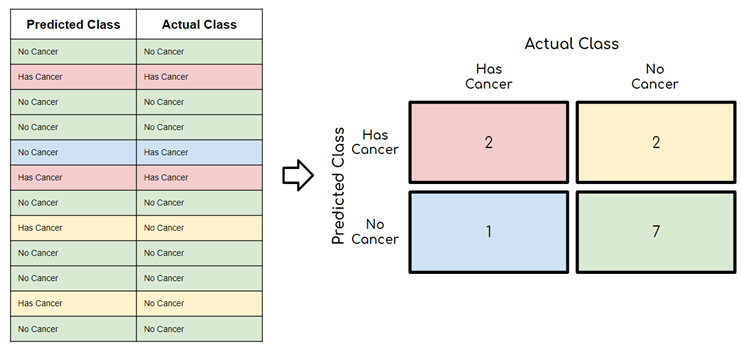

- **Exactitud** (*accuracy*).

Es la proporción de instancias correctamente clasificadas (positivas o negaticvas) entre el total de predicciones realizadas.

Mide el porcentaje de predicciones que el modelo acertó con respecto al total que hizo. Efectividad general del modelo.

$accuracy = \frac{TP + TN}{TP + TN + FP + FN}$


- **Precisión** (*precision*).

Es la proporción de instancias correctamente clasificadas positivas en relacion con todas las instancias clasificadas como positivas por el modelo.

$precision = \frac{TP}{TP + FP}$

- **Sensibilidad** (*recall*).

Es la proporción de instancias positivas correctamente clasificadas en relacion con todas las instancias que realmente son positivas.

Se interpreta como la capacidad del modelo para capturar todas las instancias positivas, sin importar las falsas alarmas ( falsos negativos).

$recall = \frac{TP}{TP + FN}$

- **Especificidad** (*specificity*).

Es la proporción de instancias negativas correctamente clasificadas en relacion con todas las instancias que realmente son negativas.

Se interpreta como la capacidad del modelo para capturar todas las instancias negativas, sin importar las falsas alarmas ( falsos positivos).

$specificity = \frac{TN}{TN + FP}$

- **Puntaje F1** (*F1 score*).

Es una métrica que combina precisión y sensibilidad. Es útil cuando hay un desbalanceo de clases.

Un valor alto de F1 indica buen equilibrio entre la capacidad de predecir instancias positivas correctamente y la capacidad de capturar todas las instancias positivas.

$F1 score = \frac{2 * (Precision * Recall)}{Precision + Recall}$


- **Área Bajo la Curva** (*AUC*):

Sirve para modelos binarios.

Es una representación gráfica del rendimiento de un modelo de clasificación en varios umbrales de decisión.

La curva ROC es una gráfica que muestra la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) para diferentes umbrales de decisión.

El AUC es el área total bajo la curva ROC y proporciona una medida agregada del rendimiento del modelo en todos los posibles umbrales.

La AUC puede interpretarse de las siguientes maneras:

- AUC = 1: El modelo tiene un rendimiento perfecto. Puede distinguir perfectamente entre las clases positivas y negativas.

- 0.5 < AUC < 1: El modelo tiene mejor rendimiento que el azar, con mayor capacidad de discriminación entre las clases.

- AUC = 0.5: El modelo no tiene capacidad de discriminación. Su rendimiento es equivalente al azar.

- AUC < 0.5: El modelo tiene peor rendimiento que el azar, lo que implica que está clasificando incorrectamente con frecuencia.

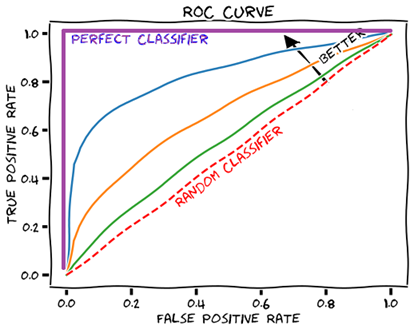

### Métricas para modelos de regresión

Un **modelo de regresión** se utiliza para predecir un valor continuo.


- **Error absoluto medio** (*Mean Absolute Error, MAE*).

Media de la diferencia absoluta entre las predicciones y los valores reales.

Es menos sensible a valores extremos que el MSE.

Valores bajos me indica que predice bien. Se equivoca poco en promedio.

   $$
   MAE = \frac{1}{n} \sum_{i=1}^n \left| y_i - \hat{y}_i \right|
   $$

- **Error cuadrático medio** (*Mean Squared Error, MSE*).

Similar al anterior, pero eleva al cuadrado las diferencias antes de realizar la división.

Penaliza más las diferencias grandes que el MAE.

Un MSE más bajo indica que las predicicones están más cerca de los valores reales en promedio. No se puede interpretar en la unidad de la variable objetivo por elevar al cuadrado.

   $$
   MSE = \frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2
   $$

- **Error cuadrático medio de la raíz** (*Root Mean Squared Error, RMSE*).

Es la raíz cuadrada del MSE.

Similar al MSE pero las unidades son las mismas que las de la variable objetivo. Fácil interpretación.

   $$
   RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2}
   $$

- **Coeficiente de determinación** ($R^2$).

Mide la proporción de la variación en la variable objetivo que es explicada por las carácterísticas del modelo.

Será un valor entre 0 y 1. Donde a más alto valor mejor predice. El modelo explica una mayor proporcion de la variabilidad de los datos.

   $$
   R^2 = 1 - \frac{\sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2}{\sum_{i=1}^n \left( y_i - \bar{y} \right)^2}
   $$

## 6. Optimización de hiperparámetros <a name="hiperparametros"></a>

Un **hiperparámetro** (*hyperparameter*) es una variable de configuración externa al modelo que se utiliza para entrenarlo.

Un **parámetro** de un modelo son las características que se optimizan para entrenarlo y que conforman su aprendizaje. Estos valores no son accesibles por nosotros como desarrolladores.

Tendremos distintos hiperparámetros disponibles según el modelo.

Optimizar los hiperparámetros será una técnica usada para buscar mejorar el rendimiento del modelo.

Tendremos distintas formas de buscar los mejores hiperparámetros.

#### 1. Búsqueda en cuadrícula (*grid search*)

Realiza una búsqueda exhaustiva a través de un subconjunto específico (establecido manualmente) de valores y luego probar todas las posibles combinaciones hasta encontrar el mejor de los modelos.

##### Pros y contras de esta estrategia

Como puntos a favor podemos encontrar:
- Exhaustividad: Prueba todas las combinaciones posibles de hiperparámetros dentro de la cuadrícula proporcionada, por lo que si la combinación óptima está dentro de ella, esta metodología la encontrará.
- Reproducibilidad: Debido a su naturaleza determinista (no aleatoria), siempre se obtendrá el mismo resultado con los mismos parámetros e input.

Sin embargo, caben destacar los siguientes puntos negativos:
- Eficiencia: Es muy costoso computacionalmente. Puede llevar mucho tiempo y requerir muchos recursos, especialmente si la cantidad de hiperparámetros es grande y/o el rango de valores es amplio.
- No garantiza llegar al mejor de los resultados, ya que depende de los hiperparámetros y de los valores que el desarrollador establezca.

#### 2. Búsqueda aleatoria (*random search*)

Similar al anterior, pero, en lugar de probar todas las combinaciones posibles de unos valores de hiperparámetros previamente establecidos, esta metodología selecciona aleatoriamente combinaciones de hiperparámetros para probar.

## 7. Regresión logística <a name="logistica"></a>

Técnica que permite realizar un **clasificador binario**.

La regresión logística es un modelo estadístico utilizado para predecir la probabilidad de que ocurra un evento binario, es decir, uno de dos posibles resultados.

**Aunque el nombre sugiere relación con la regresión lineal, la regresión logística se utiliza para problemas de clasificación binaria, no para problemas de regresión.**

Además, esta predicción se obtiene en términos de probabilidad; esto es, la probabilidad de que se dé un resultado determinado en un evento dicotómico. Luego, esta probabilidad se puede modificar para generar la predicción de una clase.

### 7.1. Función logarítmica <a name="funcion"></a>


Variable Dependiente: En la regresión logística, la variable dependiente
𝑦 representa una variable categórica binaria, típicamente codificada como 0 o 1.

Variables Independientes: Son variables predictoras 𝑋1,𝑋2,…,𝑋𝑝 que se utilizan para predecir la probabilidad de que 𝑦 sea 1.

Utiliza la función logística (también conocida como sigmoide) para modelar la relación entre las variables independientes y la probabilidad de que
𝑦 sea 1:

$$ f(x) = \frac{1}{1 + e^{-x}} $$

donde
$$
X = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n
$$

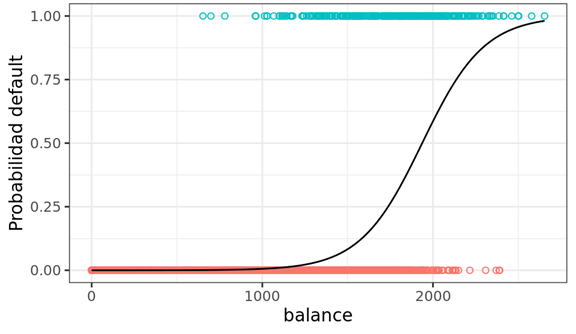

### 7.2. Umbral de decisión <a name="umbral"></a>

Dado que la regresión logística predice la probabilidad de que
𝑦 sea 1, es necesario definir un umbral (por ejemplo, 0.5) para convertir estas probabilidades en predicciones binarias (0 o 1).

Por defecto, predict() en scikit-learn utiliza un umbral de 0.5 para transformar las probabilidades pronosticadas en etiquetas binarias.

Puedes ajustar el umbral de decisión para convertir las probabilidades pronosticadas.

In [ ]:
# Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
y_proba = model.predict_proba(X_test)

# Suponiendo que deseas ajustar el umbral a 0.3
threshold = 0.3
y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# Evaluar el rendimiento con el nuevo umbral
print(accuracy_score(y_test, y_pred_threshold))
print(accuracy_score(y_test, y_pred_threshold))

### 7.3. Hiperparámetros <a name="parametros"></a>  

Podemos construir un modelo de regresión logística fácilmente en Python utilizando la librería `scikit-learn` y la función `LogisticRegression`.

Algunos de sus parámetros más importantes y los primeros en los que debemos centrarnos son:

- `penalty`: Este parámetro se usa para prevenir el sobreajuste (*overfitting*) del modelo. Este parámetro se puede configurar para que no exista penalización y para graduarla desde niveles muy leves hasta muy altos.

- `C`: Este parámetro determina la complejidad del modelo. Es el inverso del parámetro anterior. Es un número decimal que determina cómo de simple queremos que sea el modelo. Cuanto mayor sea el número, más complejo será el modelo y más se adaptará a la muestra de entrenamiento (aumentando la probabilidad del [sobreajuste](https://4geeks.com/es/lesson/basicos-de-machine-learning#Sobreajuste-de-modelos)).

- `solver`: Algoritmo de regresión que se utilizará para entrenar al modelo. Dependiendo del tamaño del conjunto de datos, de las clases a predecir, del nivel de sobreajuste que estemos dispuestos a asumir o del nivel de precisión, elegiremos una implementación u otra.

- `max_iter`: Número máximo de iteraciones.

Otro parámetro muy importante es el `random_state`, que controla la semilla de generación aleatoria que requieren algunos de los solvers del modelo. Este parámetro es crucial para asegurar la replicabilidad.

#### Ejemplo Titanic

En el conjunto de datos del Titanic tenemos más de una característica, y con la regresión logística predecimos si sobrevivirán o no.

Si el valor que predice el modelo fuera 0.85, eso significaría que la persona tiene un 85% de probabilidades de sobrevivir y un 15% de no hacerlo.

Así, debemos establecer un límite (threshold) para poder realizar la clasificación (respondemos a la siguiente pregunta: ¿a partir de qué valor de probabilidad podemos asumir que la persona sobrevive o no?).

Supongamos que ese valor es el 50%, es decir, que cuando la probabilidad es mayor o igual a 0.5, el valor es 1 (sobrevive), y cuando la probabilidad es menor a 0.5, el valor es 0 (no sobrevive).

Además, tenemos que saber también que el proceso de entrenar y usar el modelo viene después del análisis exploratorio (EDA), así que necesitaremos partir de él.

In [2]:
train_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_titanic_train.csv")
test_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_titanic_test.csv")

train_data.head()

,Pclass,Fare,Parch,Sex_n,Embarked_n,Survived
0,3.0,8.0500,0.0,0.0,0.0,0
1,1.0,164.8667,2.0,1.0,0.0,1
2,3.0,23.4500,2.0,1.0,0.0,1
3,3.0,8.4333,0.0,0.0,0.0,0
4,1.0,45.5000,0.0,0.0,0.0,0


El conjunto `train` lo utilizaremos para entrenar el modelo, mientras que con el `test` lo evaluaremos para medir su grado de efectividad. Dividiremos también las predictoras de las características.

In [3]:
X_train = train_data.drop(["Survived"], axis = 1)
y_train = train_data["Survived"]

X_test = test_data.drop(["Survived"], axis = 1)
y_test = test_data["Survived"]

##### Paso 2: Inicialización y entrenamiento del modelo

In [4]:
model = LogisticRegression(solver = 'liblinear')

model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

##### Paso 3: Predicción del modelo

Una vez se ha entrenado el modelo, se puede utilizar para predecir con el conjunto de datos de prueba.

In [5]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

Existe una gran cantidad de métricas para medir la efectividad de un modelo a la hora de predecir, entre ellas la **precisión** (*accuracy*), que es la fracción de predicciones que el modelo realizó correctamente.

In [6]:
accuracy_score(y_test, y_pred)

0.8435114503816794

In [7]:
precision_score(y_test, y_pred)

0.8222222222222222

In [8]:
recall_score(y_test, y_pred)

0.7474747474747475

In [9]:
f1_score(y_test, y_pred)

0.783068783068783

In [12]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.90      0.88       163\n           1       0.82      0.75      0.78        99\n\n    accuracy                           0.84       262\n   macro avg       0.84      0.82      0.83       262\nweighted avg       0.84      0.84      0.84       262\n'

In [10]:
nombres_clases = ["Negativa (0)", "Positiva (1)"]

print(classification_report(
    y_test,
    y_pred,
    target_names=nombres_clases,  # etiquetas legibles
    digits=3,                      # decimales
    zero_division=0                # evita warnings si hay divisiones por 0
))

              precision    recall  f1-score   support

Negativa (0)      0.855     0.902     0.878       163
Positiva (1)      0.822     0.747     0.783        99

    accuracy                          0.844       262
   macro avg      0.838     0.825     0.830       262
weighted avg      0.842     0.844     0.842       262



El modelo predice con un  85% de efectividad.

El valor anterior se interpretaría como que el modelo ha predicho, de 262 pasajeros, el resultado de supervivencia de 222 de ellos (si sobrevivían o no) correctamente.

Además de la puntuación (*score*) del modelo observada, es común que en los problemas de clasificación se construya una **matriz de confusión** (*confusion matrix*), que es una tabla que se organiza de tal manera que cada fila de la matriz representa las instancias de una clase predicha, mientras que cada columna representa las instancias de una clase real:

In [14]:
cm_df

,0,1
0,147,16
1,25,74


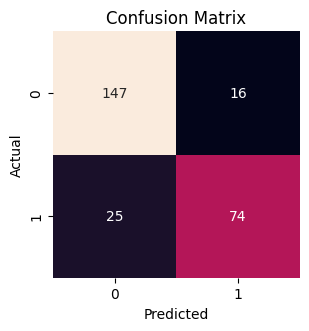

In [13]:
titanic_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(titanic_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

La interpretación de una matriz de confusión es la siguiente:

- **Verdaderos positivos** (*TP, True positive*): Se corresponde con el número `142` y son los casos en los que el modelo predijo positivo (no supervivencia) y la clase real también es positiva.
- **Verdaderos negativos** (*TN, False negative*): Se corresponde con el número `81` y son los casos en los que el modelo predijo negativo (supervivencia) y la clase real también es negativa.
- **Falsos positivos** (*FP, False positive*): Se corresponde con el número `22` y son los casos en los que el modelo predijo positivo y la clase real es negativa.
- **Falsos negativos** (*FN, False negative*): Se corresponde con el número `17` y son los casos en los que el modelo predijo negativo y la clase real es positiva.

Estas cuatro medidas se utilizan a menudo para calcular métricas más complejas.

##### Paso 4: Optimización de resultados

Como hemos visto, el modelo base (con todos los parámetros predefinidos) de la regresión logística obtiene poco más de un 84% de precisión. Sin embargo, el hecho de modificar los parámetros del modelo podría suponer una mejora (o empeoramiento) significativos de los resultados. Existen varias estrategias como los modelos regularizados.

In [15]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [18]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la cuadrícula
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [17]:
8*4*5*5

800

In [19]:
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


Como vemos, los parámetros optimizados utilizando esta técnica son:

- `C`: 1
- `penalty`: l1
- `solver`: liblinear

Además, siempre debemos utilizar el conjunto de datos de entrenamiento para ajustarlo. Ahora solo tenemos que repetir el entrenamiento estableciendo estos parámetros en el modelo:

In [20]:
model_grid = LogisticRegression(penalty = "l1", C = 0.1, solver = "liblinear")
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.8435114503816794

Observamos que no hay una gran mejora.

In [21]:
# Definimos los parámetros que queremos ajustar
hyperparams = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model, hyperparams, n_iter = 100, scoring = "accuracy", cv = 5, random_state = 42)
random_search

RandomizedSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
                   n_iter=100,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    None],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   random_state=42, scoring='accuracy')

In [22]:
random_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_search.best_params_}")

Mejores hiperparámetros: {'solver': 'newton-cg', 'penalty': 'l2', 'C': np.float64(4.281332398719396)}


Como vemos, los parámetros optimizados utilizando esta técnica son:

- `C`: 29.7635
- `penalty`: l2
- `solver`: lbfgs

Con esta nueva hiperparametrización, reentrenamos el modelo:

In [23]:
model_random_search = LogisticRegression(penalty = "l2", C = 4.28, solver = "newton-cg")
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.8435114503816794

Como vemos, arroja el mismo nivel de precisión que la estrategia anterior. Esto quiere decir que con los medios e hiperparámetros que hemos intentado optimizar nos encontramos en un **máximo local**, esto es, que tendríamos que repetir la estrategia de optimización incluyendo otros hiperparámetros para mejorar los resultados del modelo, ya que solo jugando con el `penalty`, `C` y `solver` no vamos a mejorar el modelo más de lo que ya está.

## 7. Links de interés <a name="links"></a>

- [Types of Machine Learning Algorithms ](https://pdfs.semanticscholar.org/c4ae/802491724aee021f31f02327b9671cead3dc.pdf)
- [Comprensión de la Matriz de Confusión](https://www.datasource.ai/es/data-science-articles/comprension-de-la-matriz-de-confusion-y-como-implementarla-en-python)
- [Métricas en regresión](https://medium.com/@nicolasarrioja/m%C3%A9tricas-en-regresi%C3%B3n-5e5d4259430b)
- [Understanding Overfitting and Underfitting in Machine Learning](https://medium.com/@brandon93.w/understanding-overfitting-and-underfitting-in-machine-learning-b699e0ed5b28#:~:text=Overfitting%20occurs%20when%20a%20model,generalize%20to%20new%2C%20unseen%20data.)
- [¿Qué es la regresión logística?](https://aws.amazon.com/es/what-is/logistic-regression/)
